In [1]:
%pip install langgraph openai azure-identity

  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-win_amd64.whl.metadata (2.4 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached websockets-15.0.1-cp310-cp310-win_amd64.whl.metadata (7.0 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.4-cp310-cp310-wi

In [3]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

client = OpenAI(
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    base_url=os.getenv("AZURE_OPENAI_ENDPOINT")
)

deployment_name = os.getenv("AZURE_OPENAI_DEPLOYMENT")

In [4]:
response = client.chat.completions.create(
    model=deployment_name,
    messages=[
        {
            "role": "user",
            "content": "What is the capital of France?"
        }
    ]
)

print(response.choices[0].message.content)

Paris.


In [ ]:
## Only use when you dnot have api key

# token_provider = get_bearer_token_provider(
#     DefaultAzureCredential(),
#     "https://cognitiveservices.azure.com/.default"
# )

In [ ]:
# from openai import OpenAI
# from azure.identity import DefaultAzureCredential, get_bearer_token_provider

# endpoint = "https://kafy-whatsapp-ai-dev-resource.services.ai.azure.com/openai/v1"
# deployment_name = "gpt-5-mini"

# token_provider = get_bearer_token_provider(
#     DefaultAzureCredential(),
#     "https://cognitiveservices.azure.com/.default"
# )

# client = OpenAI(
#     base_url=endpoint,
#     api_key=token_provider
# )

In [5]:
from typing import TypedDict, List

class AgentState(TypedDict):
    user_input: str
    sql_query: str
    query_result: List
    response: str

In [6]:
def user_input_node(state):
    print("User Input Node")
    
    return {
        "user_input": state["user_input"]
    }

In [7]:
def generate_query(state):

    print("Generate Query Node")

    prompt = f"""
    Convert the user request into SQL.

    Table:
    Product(
        id,
        sku,
        product_name,
        description,
        price
    )

    User Request:
    {state['user_input']}

    Return ONLY SQL.
    """

    completion = client.chat.completions.create(
        model=deployment_name,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    sql = completion.choices[0].message.content

    print("Generated SQL:")
    print(sql)

    return {
        "sql_query": sql
    }

In [ ]:
#mcp

In [8]:
def execute_query(state):
    print("Excute Query Node")

    sql=state["sql_query"]

    print(sql)

    result = [
        {
            "id":1,
            "sku":"5",
            "product_name":"QBake Bread",
            "price":25
        }
    ]

    return {
        "query_result":result
    }

In [9]:
def show_response(state):

    print("Show Response Node")

    result = state["query_result"]

    if not result:
        return {
            "response": "No products found."
        }

    product = result[0]

    response = f"""
Product: {product['product_name']}
SKU: {product['sku']}
Price: ₹{product['price']}
"""

    return {
        "response": response
    }

In [10]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

workflow.add_node("user_input",user_input_node)
workflow.add_node("generate_query",generate_query)
workflow.add_node("execute_query",execute_query)
workflow.add_node("show_response",show_response)

workflow.set_entry_point("user_input")

workflow.add_edge("user_input","generate_query")
workflow.add_edge( "generate_query","execute_query")
workflow.add_edge( "execute_query", "show_response")


workflow.add_edge( "show_response",END)

graph = workflow.compile()

In [11]:
result = graph.invoke(
    {
        "user_input": "Find details of QBake Bread"
    }
)

print("\nFinal Response:")
print(result["response"])

User Input Node
Generate Query Node
Generated SQL:
SELECT id, sku, product_name, description, price
FROM Product
WHERE product_name = 'QBake Bread';
Excute Query Node
SELECT id, sku, product_name, description, price
FROM Product
WHERE product_name = 'QBake Bread';
Show Response Node

Final Response:

Product: QBake Bread
SKU: 5
Price: ₹25



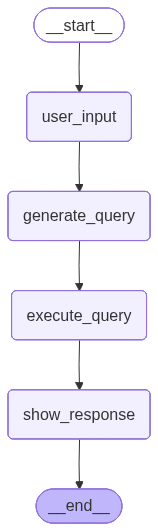

In [12]:
# show the image of the graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))